In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import seaborn as sns


import math

In [61]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

--- Visualizing One of Each Digit from X ---


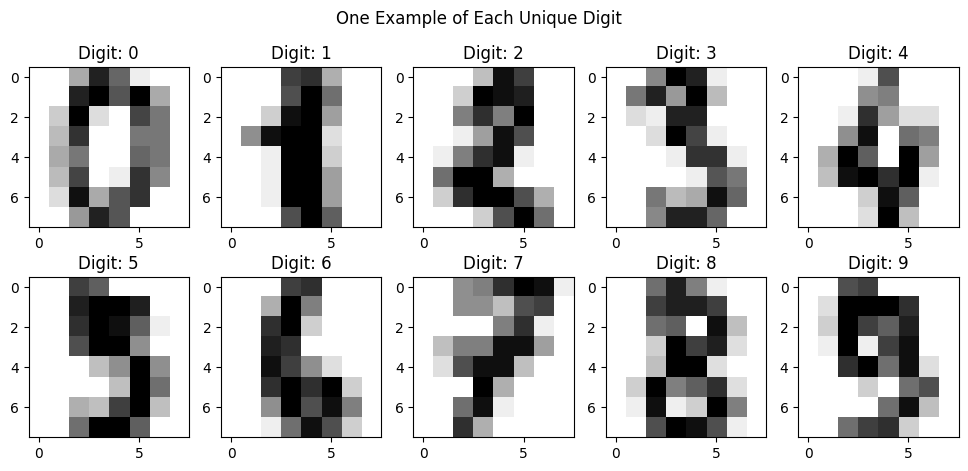

In [62]:
print("--- Visualizing One of Each Digit from X ---")
unique_digits, indices = np.unique(y, return_index=True)

plt.figure(figsize=(12, 5))
for i, index in enumerate(indices):
    image_vector = X[index]
    label = y[index]
    
    image = image_vector.reshape(8, 8) * 16.0
    # Create a 2x5 grid of subplots
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Digit: {label}')
    
plt.suptitle("One Example of Each Unique Digit")
plt.show()


In [63]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001, 'scale']
}

pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42))
])

pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
)


models = {
    "Support Vector Machine (SVM) - linear":pipe_linear,
    "Support Vector Machine (SVM) - rbf": pipe_rbf,
    "Support Vector Machine (SVM) - rbf + tuning": grid_search,
}



grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)


scores = {}
for name, model in models.items():
    print(f"{name}...", end=" ")
    model.fit(X_train, y_train)
    scores[name] = model.score(X_test, y_test)
    print(f"Accuracy: {scores[name]:.4f}")


Support Vector Machine (SVM) - linear... Accuracy: 0.9750
Support Vector Machine (SVM) - rbf... Accuracy: 0.9806
Support Vector Machine (SVM) - rbf + tuning... Accuracy: 0.9806


In [64]:
best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]
print(f"\nBest performing model: {best_model_name}")


Best performing model: Support Vector Machine (SVM) - rbf


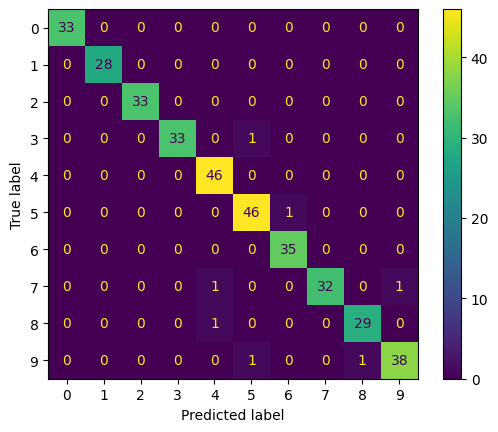

In [65]:
y_pred = best_model.predict(X_test)
class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [66]:
import pickle

with open('best_model SVM - digits.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [67]:
data_to_predict = pd.DataFrame([
      [0.    , 0.    , 0.3125, 0.8125, 0.5625, 0.0625, 0.    , 0.    ,
       0.    , 0.    , 0.8125, 0.9375, 0.625 , 0.9375, 0.3125, 0.    ,
       0.    , 0.1875, 0.9375, 0.125 , 0.    , 0.6875, 0.5   , 0.    ,
       0.    , 0.25  , 0.75  , 0.    , 0.    , 0.5   , 0.5   , 0.    ,
       0.    , 0.3125, 0.5   , 0.    , 0.    , 0.5625, 0.5   , 0.    ,
       0.    , 0.25  , 0.6875, 0.    , 0.0625, 0.75  , 0.4375, 0.    ,
       0.    , 0.125 , 0.875 , 0.3125, 0.625 , 0.75  , 0.    , 0.    ,
       0.    , 0.    , 0.375 , 0.8125, 0.625 , 0.    , 0.    , 0.    ]

])

predictions = best_model.predict(data_to_predict)

for predict in zip(predictions):
    print(f"This number is predicted to be :")
    print(f"  - {predict[0]}")
    

This number is predicted to be :
  - 0
